# 🔬 M4: Evaluation & Failure Analysis (drone vs bird)
**Computer Vision | Group Project | IE University MBDS-SEP25**

**Scope:** Test-set evaluation, confusion matrix, failure-case gallery, error-by-size analysis

This notebook evaluates the YOLOv11s detector trained in M3 on the held-out test split (278 images, 302 objects). We report all four mandatory metrics (mAP50, mAP50-95, precision, and recall) and go beyond the numbers with a confusion matrix, a categorised failure gallery, and a size-stratified error analysis.

**Why evaluate on the test set and not the validation set?**
The validation set is used during training to pick the best checkpoint, so its metrics are optimistic: the model has implicitly "seen" them through the checkpoint-selection process. The test set is completely held out and untouched until this notebook, giving an unbiased estimate of real-world performance.

**Why analyse failure cases by category?**
Aggregate metrics can hide the direction of errors. For counter-UAV, a drone missed entirely is a critical security failure; a bird wrongly flagged as a drone is a false alarm that increases operator workload. Understanding which errors occur, and why, tells us where the model needs improvement and whether those improvements are possible through threshold tuning or require more data.

## 0 · Setup

In [1]:
!pip install -q "ultralytics>=8.3.0,<9.0.0" "PyYAML>=6.0" "matplotlib>=3.7.0" "pandas>=2.0" "seaborn>=0.12"

import ultralytics
ultralytics.checks()
print(f"Ultralytics version: {ultralytics.__version__}")

Ultralytics 8.4.82 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 47.1/112.6 GB disk)
Ultralytics version: 8.4.82


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os
import yaml

DRIVE_ROOT  = "/content/drive/MyDrive/!CVIS"
DATA_DIR    = f"{DRIVE_ROOT}/data/processed"
DATA_YAML   = f"{DATA_DIR}/data.yaml"
MODELS_DIR  = f"{DRIVE_ROOT}/models"

LOCAL_RUNS  = "/content/runs"
RESULTS_DIR = f"{DRIVE_ROOT}/results"
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(LOCAL_RUNS, exist_ok=True)


BEST_S = f"{MODELS_DIR}/best_s.pt"
BEST_N = f"{MODELS_DIR}/best_n.pt"

assert os.path.isdir(DATA_DIR), (
    f"Dataset directory not found: {DATA_DIR}\n"
    "The !CVIS folder is shared by a teammate. In Google Drive, open 'Shared with me',\n"
    "right-click !CVIS, choose 'Add shortcut to Drive', place it in My Drive, then\n"
    "'Runtime > Disconnect and delete runtime' and re-run from the top."
)
assert os.path.exists(DATA_YAML), f"data.yaml not found at {DATA_YAML}"
assert os.path.exists(BEST_S), (
    f"Primary weights not found: {BEST_S}\n"
    "Run notebook 02 (M3) to train and export best_s.pt to the shared Drive first."
)

# Confirm the test split exists and load class names from the SAME yaml used for training.
TEST_IMG_DIR = f"{DATA_DIR}/test/images"
TEST_LBL_DIR = f"{DATA_DIR}/test/labels"
assert os.path.isdir(TEST_IMG_DIR), f"Test images not found at {TEST_IMG_DIR}"
assert os.path.isdir(TEST_LBL_DIR), f"Test labels not found at {TEST_LBL_DIR}"

with open(DATA_YAML) as f:
    data_cfg = yaml.safe_load(f)
NAMES = data_cfg["names"] if isinstance(data_cfg["names"], list) else [data_cfg["names"][i] for i in sorted(data_cfg["names"])]
print("Classes (index → name):", {i: n for i, n in enumerate(NAMES)})

# Hard guard on the project-wide class convention.
assert [n.lower() for n in NAMES] == ["bird", "drone"], (
    f"Unexpected class order {NAMES}. The project convention is bird=0, drone=1; "
    "check data.yaml before trusting any metric below."
)
BIRD_ID, DRONE_ID = 0, 1

n_test = len([x for x in os.listdir(TEST_IMG_DIR) if x.lower().endswith(('.jpg', '.jpeg', '.png'))])
print(f"\n✅ Setup OK. Test split: {n_test} images. Evaluating primary model: {BEST_S}")

Classes (index → name): {0: 'bird', 1: 'drone'}

✅ Setup OK. Test split: 278 images. Evaluating primary model: /content/drive/MyDrive/!CVIS/models/best_s.pt


In [4]:
# --- Stage the test split on the LOCAL VM disk -------------------------------

import shutil

USE_LOCAL_STAGE = True

if USE_LOCAL_STAGE:
    LOCAL_DATA = "/content/cvis_eval"
    for sub in ("test/images", "test/labels"):
        s_dir, d_dir = f"{DATA_DIR}/{sub}", f"{LOCAL_DATA}/{sub}"
        if not os.path.isdir(d_dir):
            os.makedirs(os.path.dirname(d_dir), exist_ok=True)
            shutil.copytree(s_dir, d_dir)

    EVAL_YAML = f"{LOCAL_DATA}/data.yaml"
    with open(EVAL_YAML, "w") as f:
        # All three splits point to test/images intentionally; this yaml is only used
        # with split="test" in model.val(). Do not pass split="train" or split="val" here.
        yaml.safe_dump({"path": LOCAL_DATA, "train": "test/images",
                        "val": "test/images", "test": "test/images",
                        "nc": len(NAMES), "names": NAMES}, f, sort_keys=False)
    TEST_IMG_DIR = f"{LOCAL_DATA}/test/images"
    TEST_LBL_DIR = f"{LOCAL_DATA}/test/labels"
else:
    EVAL_YAML = DATA_YAML

n_local = len([x for x in os.listdir(TEST_IMG_DIR)
               if x.lower().endswith(('.jpg', '.jpeg', '.png'))])
print(f"Eval data.yaml : {EVAL_YAML}")
print(f"Test images ready: {n_local} at {TEST_IMG_DIR}")

Eval data.yaml : /content/cvis_eval/data.yaml
Test images ready: 278 at /content/cvis_eval/test/images


##  1 · Test-Set Metrics

We run the detector on the **test** split and report four metrics:

- **Precision**: of the boxes called *drone*, how many really were. Low = false alarms on birds.
- **Recall**: of the real drones, how many we caught. Low = missed threats (the costly failure for counter-UAV).
- **mAP50**: detection quality at IoU ≥ 0.50 (found it and roughly localised it).
- **mAP50-95**: same, averaged over stricter IoU thresholds, so it measures how *tight* the boxes are.


In [5]:
from ultralytics import YOLO

model_s = YOLO(BEST_S)

metrics_s = model_s.val(
    data    = EVAL_YAML,
    split   = "test",
    project = LOCAL_RUNS,
    name    = "eval_test_s",
    plots   = True,
    conf    = 0.001,      # low threshold so the PR curve / mAP integrate the full curve
    iou     = 0.6,        # NMS IoU
    verbose = True,
)
EVAL_S_DIR = metrics_s.save_dir
print("Run folder:", EVAL_S_DIR)

for fig in ["confusion_matrix.png", "confusion_matrix_normalized.png",
            "PR_curve.png", "F1_curve.png", "P_curve.png", "R_curve.png"]:
    fsrc = os.path.join(str(EVAL_S_DIR), fig)
    if os.path.exists(fsrc):
        shutil.copy(fsrc, f"{RESULTS_DIR}/test_s_{fig}")
print("Figures copied to:", RESULTS_DIR)

Ultralytics 8.4.82 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s summary (fused): 101 layers, 9,413,574 parameters, 0 gradients, 21.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 835.2±396.3 MB/s, size: 20.4 KB)
val: Scanning /content/cvis_eval/test/labels... 278 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 278/278 1.8Kit/s 0.2s
val: New cache created: /content/cvis_eval/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 18/18 3.2it/s 5.6s
                   all        278        302      0.955      0.971       0.98      0.617
                  bird         79        103      0.942      0.942      0.966      0.644
                 drone        199        199      0.968          1      0.993      0.589
Speed: 2.0ms preprocess, 8.9ms inference, 0.0ms loss, 1.4ms postprocess per image
Results saved to /content/runs/eval_test_s
Run folder: /content/runs/eval_test_s
Figure

In [6]:
import pandas as pd

def overall_row(m, label):
    d = m.results_dict
    return {
        "Model":     label,
        "mAP50":     round(d.get("metrics/mAP50(B)",    0.0), 4),
        "mAP50-95":  round(d.get("metrics/mAP50-95(B)", 0.0), 4),
        "Precision": round(d.get("metrics/precision(B)",0.0), 4),
        "Recall":    round(d.get("metrics/recall(B)",   0.0), 4),
    }

def per_class_table(m, names):
    rows = []
    for i, c in enumerate(m.box.ap_class_index):
        p, r, ap50, ap = m.box.class_result(i)
        rows.append({
            "Class":     names[c],
            "Precision": round(p, 4),
            "Recall":    round(r, 4),
            "mAP50":     round(ap50, 4),
            "mAP50-95":  round(ap, 4),
        })
    return pd.DataFrame(rows)

overall_s = pd.DataFrame([overall_row(metrics_s, "YOLOv11s (test)")])
perclass_s = per_class_table(metrics_s, NAMES)

print("OVERALL: test set")
display(overall_s.set_index("Model"))
print("\nPER-CLASS: test set")
display(perclass_s.set_index("Class"))

# Persist for the slides / repo results/ folder.
overall_s.to_csv(f"{RESULTS_DIR}/test_metrics_overall_s.csv", index=False)
perclass_s.to_csv(f"{RESULTS_DIR}/test_metrics_perclass_s.csv", index=False)
print(f"\n💾 Saved metric CSVs to {RESULTS_DIR}/")

OVERALL: test set


,mAP50,mAP50-95,Precision,Recall
Model,,,,
YOLOv11s (test),0.9796,0.6169,0.9547,0.9711



PER-CLASS: test set


,Precision,Recall,mAP50,mAP50-95
Class,,,,
bird,0.9418,0.9422,0.9660,0.6444
drone,0.9677,1.0000,0.9931,0.5894



💾 Saved metric CSVs to /content/drive/MyDrive/!CVIS/results/


On 278 unseen test images (302 objects), the detector achieves mAP50 = 0.98, with 0.95 precision and 0.97 recall, confirming that the M3 validation performance generalises well to unseen data without evidence of overfitting. Most importantly, drone recall reaches 1.00, meaning every drone in the test set was detected, with a drone mAP50 of 0.99.

The main limitation is the gap between mAP50 (0.98) and mAP50–95 (0.62), indicating reliable detection but less precise localisation at stricter IoU thresholds. This is particularly evident for drones, which achieve higher mAP50 but lower mAP50–95 than birds (0.59 vs. 0.64), reflecting the challenge of tightly localising small, distant targets where minor box offsets significantly reduce IoU. Birds remain the weaker, minority class across all metrics and account for most residual errors.

## 2 · Confusion Matrix

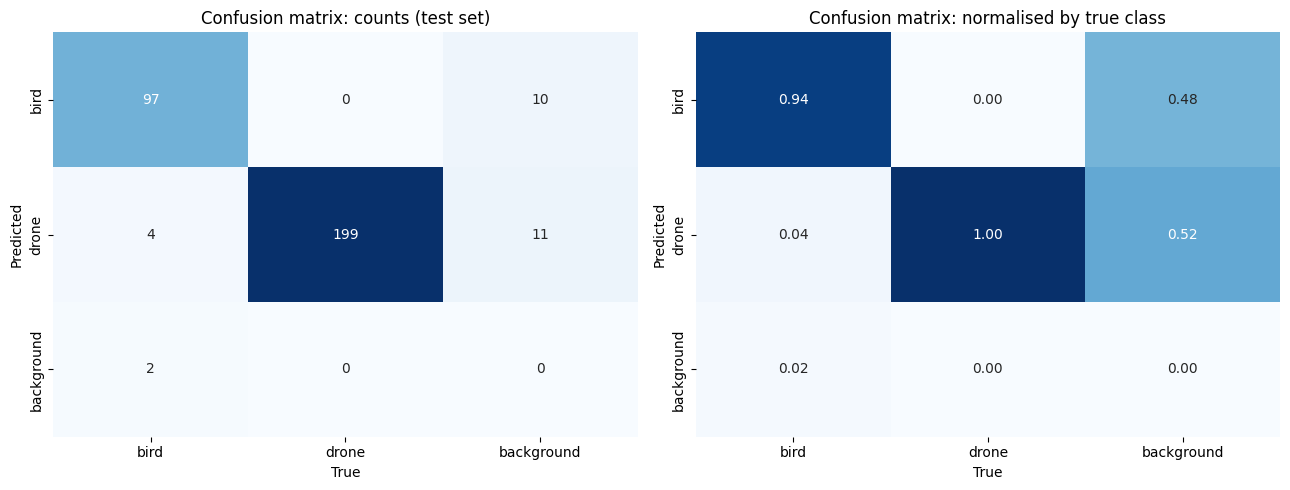

birds  called drone (false alarm)      : 4
drones called bird  (misclassification): 0
drones missed entirely (→ background)  : 0
birds  missed entirely (→ background)  : 2


In [7]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Rebuild from the validator object so labels are guaranteed correct.
# ultralytics ConfusionMatrix.matrix has shape (nc+1, nc+1): index nc == background.
cm = metrics_s.confusion_matrix.matrix.astype(int)
labels = NAMES + ["background"]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Raw counts
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels, yticklabels=labels, cbar=False, ax=axes[0])
axes[0].set_title("Confusion matrix: counts (test set)")
axes[0].set_xlabel("True"); axes[0].set_ylabel("Predicted")

# Column-normalised (per true class) → reads as "of all real birds, how were they predicted"
col_sum = cm.sum(axis=0, keepdims=True)
cm_norm = np.divide(cm, col_sum, out=np.zeros_like(cm, dtype=float), where=col_sum != 0)
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=labels, yticklabels=labels, cbar=False, ax=axes[1])
axes[1].set_title("Confusion matrix: normalised by true class")
axes[1].set_xlabel("True"); axes[1].set_ylabel("Predicted")

plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/confusion_matrix_test_s.png", dpi=150, bbox_inches="tight")
plt.show()

# Pull out the headline confusion numbers for the write-up.
bird_as_drone = cm[DRONE_ID, BIRD_ID]      # predicted drone, truly bird  → classic false alarm
drone_as_bird = cm[BIRD_ID, DRONE_ID]      # predicted bird,  truly drone → dangerous miss-classification
drone_missed  = cm[len(NAMES), DRONE_ID]   # predicted background, truly drone → missed threat
bird_missed   = cm[len(NAMES), BIRD_ID]
print(f"birds  called drone (false alarm)      : {bird_as_drone}")
print(f"drones called bird  (misclassification): {drone_as_bird}")
print(f"drones missed entirely (→ background)  : {drone_missed}")
print(f"birds  missed entirely (→ background)  : {bird_missed}")

The error direction is more important than the error count. All class confusions are conservative: 4 birds were classified as drones, while no drones were classified as birds and no drones were missed. For counter-UAV use, this is the preferred failure profile: the system does not let drones pass undetected; its mistakes are additional bird false alarms that an operator can dismiss. The main operational cost is therefore the bird→drone confusion, which may contribute to alarm fatigue, while the empty drone-error row is the key security result.

## 3 · PR & F1 Curves

The PR curve shows how much precision survives as we push recall up; the F1 curve shows which confidence threshold balances them best. We use that threshold to pick the single operating `conf` for the live demo.

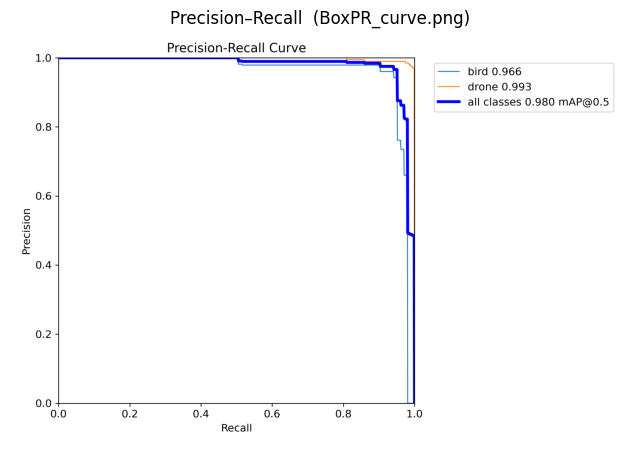

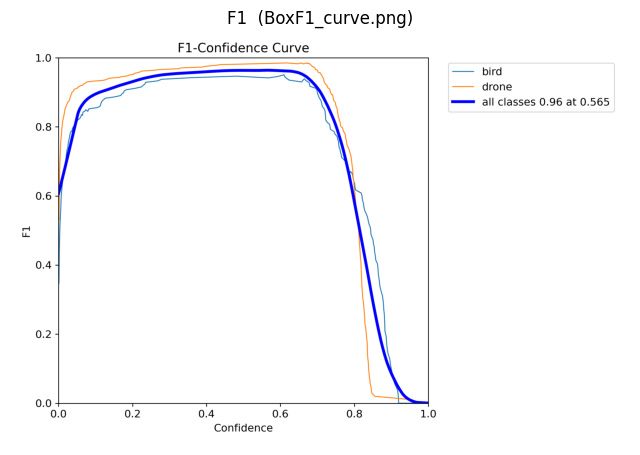

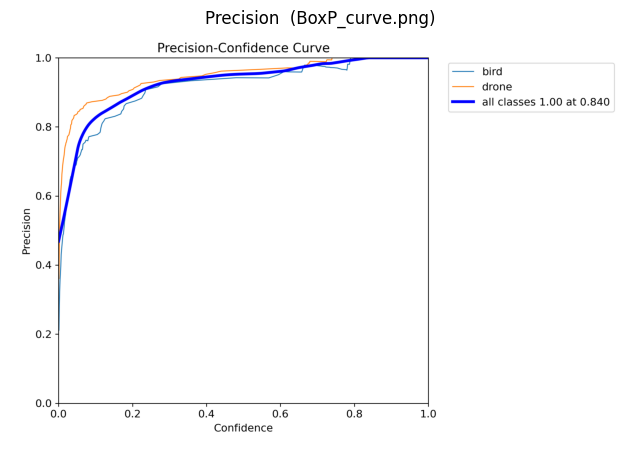

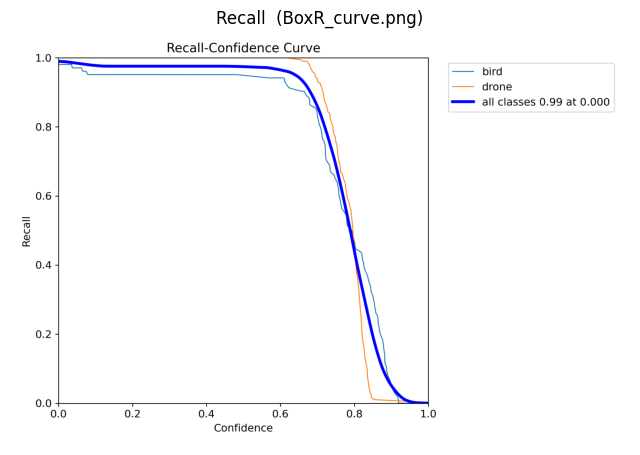

In [8]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

curve_files = {
    "Precision–Recall": ["BoxPR_curve.png", "PR_curve.png"],
    "F1":               ["BoxF1_curve.png", "F1_curve.png"],
    "Precision":        ["BoxP_curve.png",  "P_curve.png"],
    "Recall":           ["BoxR_curve.png",  "R_curve.png"],
}
for label, candidates in curve_files.items():
    for fn in candidates:
        fpath = os.path.join(str(EVAL_S_DIR), fn)
        if os.path.exists(fpath):
            img = mpimg.imread(fpath)
            plt.figure(figsize=(8, 6))
            plt.imshow(img); plt.axis("off"); plt.title(f"{label}  ({fn})")
            plt.show()
            break
    else:
        print(f"(not found: {label} curve)")

## 4 · Failure-Case Gallery

Metrics quantify performance, but they do not reveal the nature of the errors. To go beyond the numbers, we run the detector on the test set at the demo operating threshold (**conf = 0.25**), match predictions to ground truth by IoU, and assign each error to one of four categories:

| **Error category**   | **Definition**                                                                            |
| :------------------- | :---------------------------------------------------------------------------------------- |
| **Bird → Drone**     | A bird is incorrectly classified as a drone (false positive).                             |
| **Drone → Bird**     | A drone is incorrectly classified as a bird (misclassification).                          |
| **Missed detection** | A ground-truth object is not matched by any prediction (false negative).                  |
| **Ghost detection**  | A predicted bounding box does not correspond to any ground-truth object (false positive). |


The most representative examples from each category are shown below, with **ground-truth boxes in green** and **predictions in red**, so each error type is immediately visible.

In [9]:
import glob

CONF_OP   = 0.25   # operating confidence for the gallery (matches the demo default)
MATCH_IOU = 0.50   # IoU threshold to call a prediction a match to a GT box

def load_gt(label_path, W, H):
    # Read a YOLO-format label file -> list of (cls, [x1,y1,x2,y2], area_frac).
    boxes = []
    if not os.path.exists(label_path):
        return boxes
    for line in open(label_path):
        parts = line.split()
        if len(parts) < 5:
            continue
        cls, cx, cy, w, h = int(parts[0]), *map(float, parts[1:5])
        x1, y1 = (cx - w / 2) * W, (cy - h / 2) * H
        x2, y2 = (cx + w / 2) * W, (cy + h / 2) * H
        boxes.append((cls, [x1, y1, x2, y2], w * h))   # w*h (normalised) == area fraction
    return boxes

def iou(a, b):
    ix1, iy1 = max(a[0], b[0]), max(a[1], b[1])
    ix2, iy2 = min(a[2], b[2]), min(a[3], b[3])
    iw, ih = max(0.0, ix2 - ix1), max(0.0, iy2 - iy1)
    inter = iw * ih
    if inter == 0:
        return 0.0
    area_a = (a[2] - a[0]) * (a[3] - a[1])
    area_b = (b[2] - b[0]) * (b[3] - b[1])
    return inter / (area_a + area_b - inter)

test_imgs = sorted(glob.glob(f"{TEST_IMG_DIR}/*.jpg") +
                   glob.glob(f"{TEST_IMG_DIR}/*.jpeg") +
                   glob.glob(f"{TEST_IMG_DIR}/*.png"))
assert test_imgs, f"No test images found at {TEST_IMG_DIR}"
print(f"Scanning {len(test_imgs)} test images at conf={CONF_OP}, IoU match={MATCH_IOU} ...")

Scanning 278 test images at conf=0.25, IoU match=0.5 ...


In [10]:
import cv2

# Per-object detection records and per-image failure cases (for the gallery).
gt_records   = []   # one row per ground-truth object: {class, area_frac, detected, confused}
failures     = {"bird_as_drone": [], "drone_as_bird": [], "missed": [], "ghost": []}

# Batch inference with stream=True avoids holding all 278 results in memory simultaneously.
for img_path, res in zip(test_imgs, model_s.predict(test_imgs, conf=CONF_OP, iou=0.6,
                                                      verbose=False, stream=True)):
    H, W  = res.orig_shape          # image dimensions from the result object
    stem  = os.path.splitext(os.path.basename(img_path))[0]
    gts   = load_gt(f"{TEST_LBL_DIR}/{stem}.txt", W, H)

    preds = []
    for b in res.boxes:
        preds.append((int(b.cls[0]), float(b.conf[0]), [float(v) for v in b.xyxy[0]]))
    preds.sort(key=lambda p: -p[1])           # greedily match highest-confidence preds first

    matched_pred = [False] * len(preds)
    for gcls, gbox, gframe in gts:
        best_j, best_iou = -1, MATCH_IOU
        for j, (pcls, pconf, pbox) in enumerate(preds):
            if matched_pred[j]:
                continue
            v = iou(gbox, pbox)
            if v >= best_iou:
                best_iou, best_j = v, j
        detected = best_j != -1
        confused = detected and preds[best_j][0] != gcls
        gt_records.append({"class": gcls, "area_frac": gframe,
                           "detected": detected, "confused": confused})
        if detected:
            matched_pred[best_j] = True
            if confused:
                if gcls == BIRD_ID:   # truly bird, predicted drone
                    failures["bird_as_drone"].append((img_path, gts, preds))
                else:                 # truly drone, predicted bird
                    failures["drone_as_bird"].append((img_path, gts, preds))
        else:
            failures["missed"].append((img_path, gts, preds))

    # Unmatched predictions = ghost boxes. One entry per image (not per box); a single
    # image may contain multiple unmatched boxes; we log it once for the gallery.
    for j, (pcls, pconf, pbox) in enumerate(preds):
        if not matched_pred[j]:
            failures["ghost"].append((img_path, gts, preds))
            break

n_gt = len(gt_records)
print(f"Ground-truth objects scanned: {n_gt}")
for k, v in failures.items():
    print(f"  {k:14s}: {len(v)} image(s)")

Ground-truth objects scanned: 302
  bird_as_drone : 5 image(s)
  drone_as_bird : 0 image(s)
  missed        : 2 image(s)
  ghost         : 17 image(s)


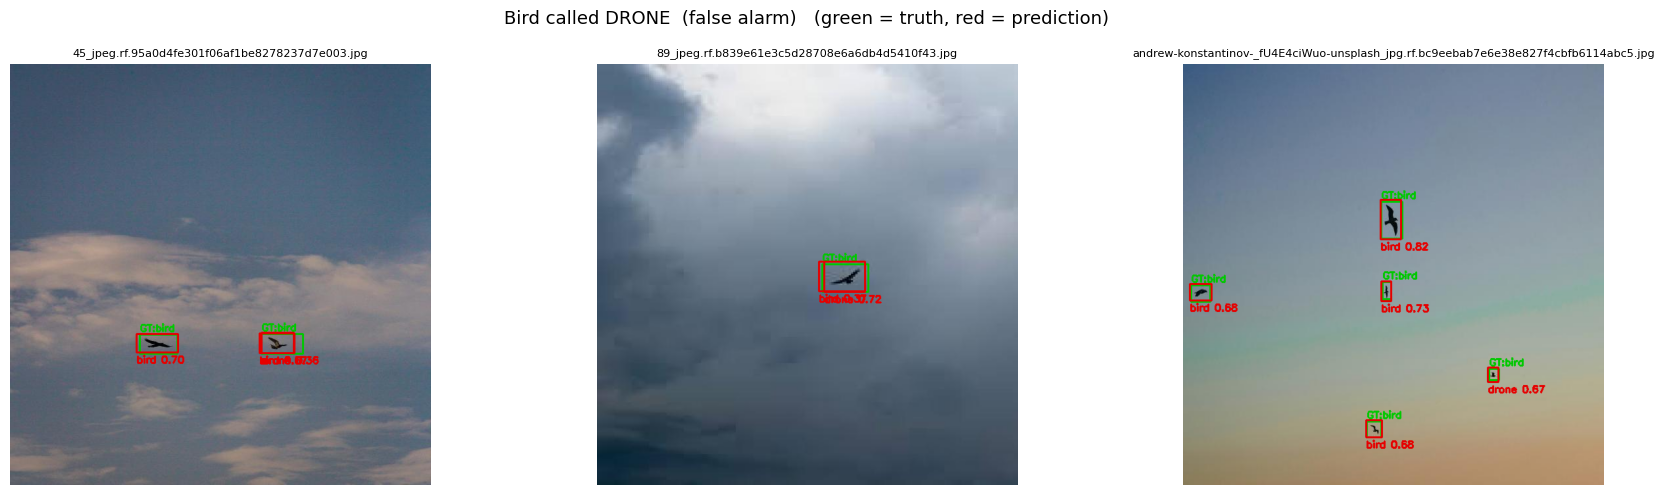

💾 /content/drive/MyDrive/!CVIS/results/failures_bird_as_drone.png
✅ No 'drone_as_bird' cases found at conf=0.25. Nothing to show.


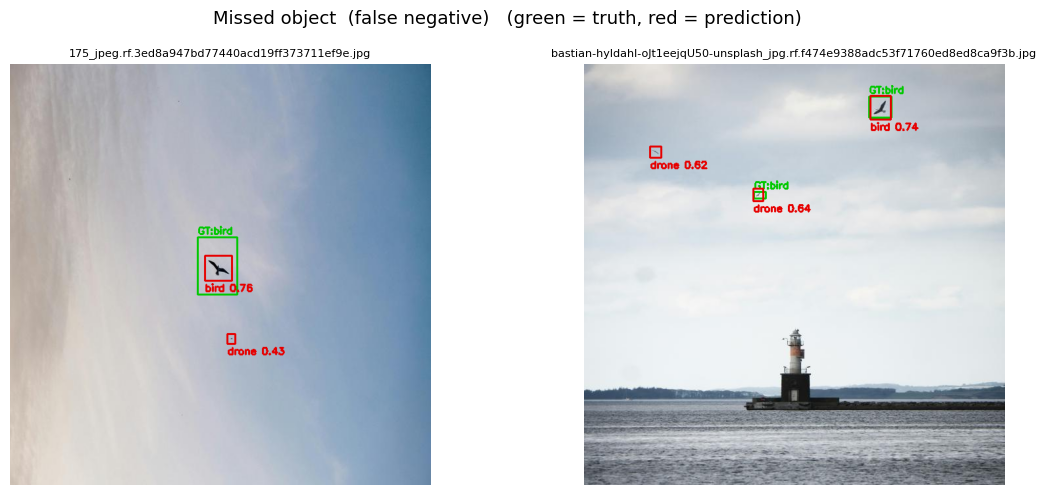

💾 /content/drive/MyDrive/!CVIS/results/failures_missed.png


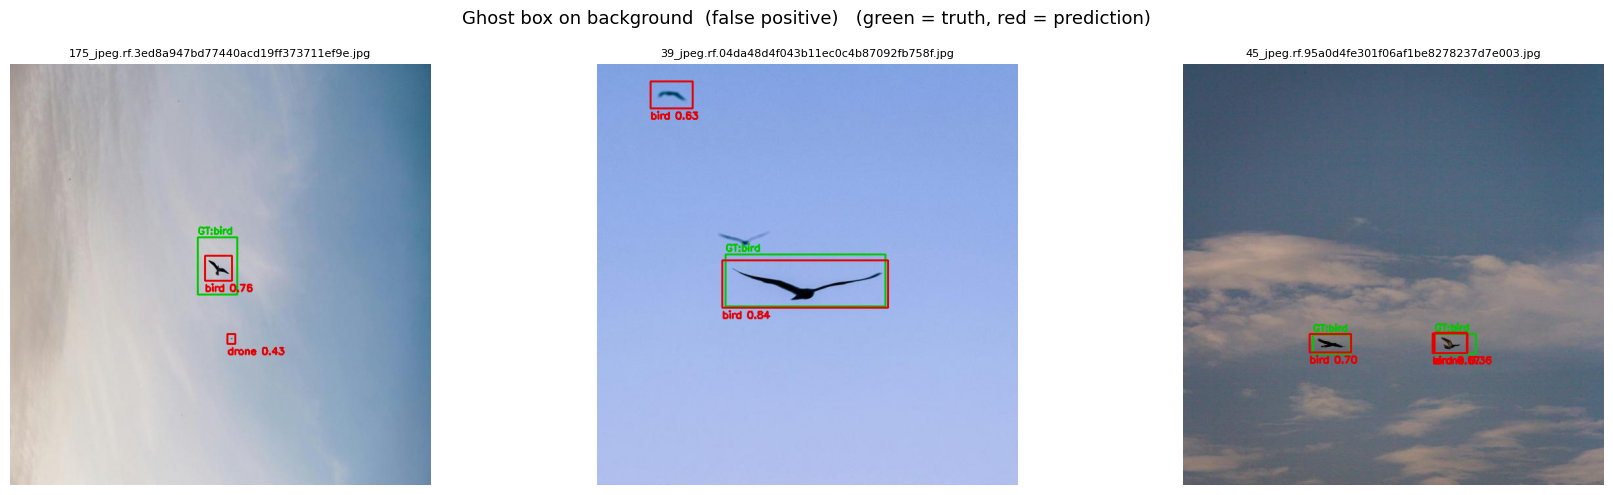

💾 /content/drive/MyDrive/!CVIS/results/failures_ghost.png


In [11]:
GREEN = (0, 200, 0)     # ground truth
RED   = (0, 0, 230)      # prediction (BGR)

def annotate(img_path, gts, preds):
    im = cv2.imread(img_path)
    for cls, box, _ in gts:
        x1, y1, x2, y2 = map(int, box)
        cv2.rectangle(im, (x1, y1), (x2, y2), GREEN, 2)
        cv2.putText(im, f"GT:{NAMES[cls]}", (x1, max(0, y1 - 5)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, GREEN, 2)
    for cls, conf, box in preds:
        x1, y1, x2, y2 = map(int, box)
        cv2.rectangle(im, (x1, y1), (x2, y2), RED, 2)
        cv2.putText(im, f"{NAMES[cls]} {conf:.2f}", (x1, min(im.shape[0] - 5, y2 + 16)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, RED, 2)
    return cv2.cvtColor(im, cv2.COLOR_BGR2RGB)

TITLES = {
    "bird_as_drone": "Bird called DRONE  (false alarm)",
    "drone_as_bird": "Drone called BIRD  (misclassified threat)",
    "missed":        "Missed object  (false negative)",
    "ghost":         "Ghost box on background  (false positive)",
}

def show_gallery(kind, n=3):
    items = failures[kind][:n]
    if not items:
        print(f"✅ No '{kind}' cases found at conf={CONF_OP}. Nothing to show.")
        return
    fig, axes = plt.subplots(1, len(items), figsize=(6 * len(items), 5))
    if len(items) == 1:
        axes = [axes]
    for ax, (p, gts, preds) in zip(axes, items):
        ax.imshow(annotate(p, gts, preds))
        ax.set_title(os.path.basename(p), fontsize=8)
        ax.axis("off")
    fig.suptitle(TITLES[kind] + "   (green = truth, red = prediction)", fontsize=13)
    plt.tight_layout()
    out = f"{RESULTS_DIR}/failures_{kind}.png"
    plt.savefig(out, dpi=130, bbox_inches="tight")
    plt.show()
    print(f"💾 {out}")

for kind in ["bird_as_drone", "drone_as_bird", "missed", "ghost"]:
    show_gallery(kind, n=3)

At the demo operating threshold (**conf = 0.25**), no drone is misclassified as a bird, while only **5 bird images** are labelled as drones, and most appear to be duplicate detections of the same bird. The dominant error category is **ghost detections**: the **17 ghost detections** identified at **conf = 0.25** do not all correspond to genuine background false positives. Visual inspection reveals three distinct causes.

First, some are **true hallucinations**, where low-confidence detections appear over sky textures or treeline clutter; these are genuine detector errors and could be reduced by increasing the confidence threshold or applying stricter NMS.

Second, some detections correspond to **real but unlabelled objects**, typically birds omitted during annotation. These are counted as ghosts despite representing correct detections, highlighting a limitation in the dataset rather than the model.

Third, some ghosts arise from **duplicate or loosely localised detections**: after matching the best prediction to the ground truth, additional overlapping boxes (or boxes with IoU below 0.5) are counted as false positives. This behaviour is consistent with the lower **mAP50–95**, which indicates reduced localisation accuracy on small objects.

Overall, the reported ghost count overestimates the rate of true background false alarms, as it combines detector hallucinations with annotation gaps and localisation artefacts. Only the first category represents a failure mode that should be addressed through model tuning.

## 5 · Error by Object Size

Distant (small) targets are the hard case for counter-UAV, so we measure performance as a function of size. Reusing the IoU matching from failure analysis, we bin every ground-truth object by **relative area** (box area ÷ image area, so it's comparable across resolutions) and compute, per bin and class, the **detection rate** (recall) and the **confusion rate** (detected but wrong class).

Bins: `tiny <0.1%`, `small 0.1–1%`, `medium 1–5%`, `large >5%`.

In [12]:
df = pd.DataFrame(gt_records)
df["class_name"] = df["class"].map({BIRD_ID: "bird", DRONE_ID: "drone"})

bins   = [0, 0.001, 0.01, 0.05, 1.0]
labels_sz = ["tiny\n(<0.1%)", "small\n(0.1-1%)", "medium\n(1-5%)", "large\n(>5%)"]
df["size_bin"] = pd.cut(df["area_frac"], bins=bins, labels=labels_sz, include_lowest=True)

# Detection rate (recall) and confusion rate per (size, class).
agg = (df.groupby(["size_bin", "class_name"], observed=True)
         .agg(n=("detected", "size"),
              detection_rate=("detected", "mean"),
              confusion_rate=("confused", "mean"))
         .reset_index())
print("Per size-bin × class:")
display(agg)

agg.to_csv(f"{RESULTS_DIR}/error_by_size.csv", index=False)

Per size-bin × class:


,size_bin,class_name,n,detection_rate,confusion_rate
0,tiny\n(<0.1%),bird,4,0.750000,0.250000
1,tiny\n(<0.1%),drone,2,1.000000,0.000000
2,small\n(0.1-1%),bird,49,1.000000,0.081633
3,small\n(0.1-1%),drone,194,1.000000,0.000000
4,medium\n(1-5%),bird,31,0.967742,0.000000
5,medium\n(1-5%),drone,2,1.000000,0.000000
6,large\n(>5%),bird,19,1.000000,0.000000
7,large\n(>5%),drone,1,1.000000,0.000000


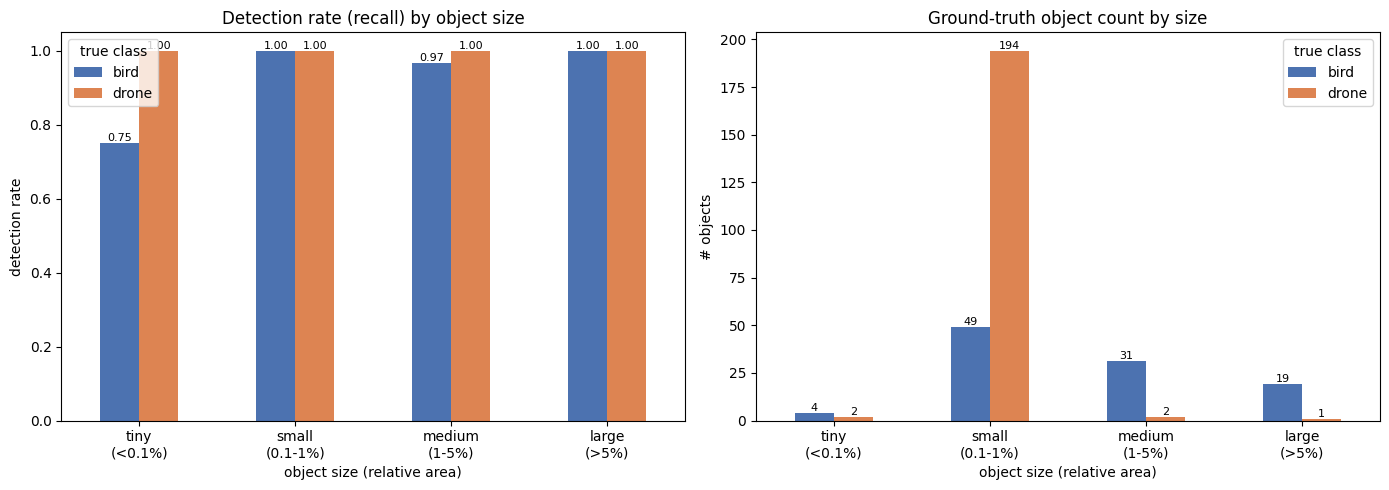

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Detection rate vs size
piv_det = agg.pivot(index="size_bin", columns="class_name", values="detection_rate")
piv_det.plot(kind="bar", ax=axes[0], color={"bird": "#4C72B0", "drone": "#DD8452"}, rot=0)
axes[0].set_title("Detection rate (recall) by object size")
axes[0].set_ylabel("detection rate"); axes[0].set_ylim(0, 1.05)
axes[0].set_xlabel("object size (relative area)")
axes[0].legend(title="true class")
for c in axes[0].containers:
    axes[0].bar_label(c, fmt="%.2f", fontsize=8)

# Object count per bin (context: are the small bins well-populated?)
piv_n = agg.pivot(index="size_bin", columns="class_name", values="n")
piv_n.plot(kind="bar", ax=axes[1], color={"bird": "#4C72B0", "drone": "#DD8452"}, rot=0)
axes[1].set_title("Ground-truth object count by size")
axes[1].set_ylabel("# objects"); axes[1].set_xlabel("object size (relative area)")
axes[1].legend(title="true class")
for c in axes[1].containers:
    axes[1].bar_label(c, fontsize=8)

plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/error_by_size.png", dpi=150, bbox_inches="tight")
plt.show()

Detection recall remains near-perfect across object sizes: drone recall is **1.00** in every size bin, while bird recall decreases only for the smallest objects. The main size-dependent effect is therefore **bird→drone misclassification**, which is confined to *tiny* (1/4) and *small* (4/49) birds and disappears for medium and large targets. In practice, the model rarely fails to detect an object but occasionally misclassifies small, low-contrast birds as drones.

Two caveats apply. First, the size distribution is highly imbalanced: **243 of 302 objects** belong to the *small* category, whereas the *tiny* bin contains only **6 objects**, so the lower recall for tiny birds (3/4) should be interpreted cautiously. Second, recall does not reflect localisation quality. The lower **mAP50–95** indicates that bounding-box accuracy also degrades on small objects, even when they are successfully detected. These findings motivate the small-object improvements proposed in **M5**, including SAHI tiling and higher-resolution inference.

## 6 · s vs n on the Test Set

M3 compared YOLOv11s and YOLOv11n on the validation set, where nano was marginally ahead. Here we extend that comparison to the test set.

In [14]:
rows = [overall_row(metrics_s, "YOLOv11s (test)")]

if os.path.exists(BEST_N):
    model_n   = YOLO(BEST_N)
    metrics_n = model_n.val(data=EVAL_YAML, split="test", project=LOCAL_RUNS,
                            name="eval_test_n", plots=False, conf=0.001, iou=0.6, verbose=False)
    rows.append(overall_row(metrics_n, "YOLOv11n (test)"))
    # Model size on disk (MB) for the speed/footprint argument.
    sz_s = round(os.path.getsize(BEST_S) / 1e6, 1)
    sz_n = round(os.path.getsize(BEST_N) / 1e6, 1)
    print(f"Model size: s={sz_s} MB, n={sz_n} MB")
else:
    print("best_n.pt not found. Showing primary model only.")

cmp = pd.DataFrame(rows).set_index("Model")
display(cmp)
cmp.to_csv(f"{RESULTS_DIR}/test_metrics_scale_comparison.csv")

Ultralytics 8.4.82 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,582,542 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1698.3±540.1 MB/s, size: 43.6 KB)
val: Scanning /content/cvis_eval/test/labels.cache... 278 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 278/278 89.7Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 18/18 6.9it/s 2.6s
                   all        278        302      0.941      0.944      0.971      0.609
Speed: 1.0ms preprocess, 4.7ms inference, 0.0ms loss, 1.2ms postprocess per image
Model size: s=19.2 MB, n=5.5 MB


,mAP50,mAP50-95,Precision,Recall
Model,,,,
YOLOv11s (test),0.9796,0.6169,0.9547,0.9711
YOLOv11n (test),0.9713,0.6087,0.9411,0.9439


On the test set, **YOLOv11n** and **YOLOv11s** achieve similar detection accuracy: nano reaches **mAP50 = 0.971** and **mAP50–95 = 0.609**, compared with **0.980** and **0.617** for small. The ~0.009 mAP50 gap across 302 test objects is within sampling noise and should not be read as a definitive ranking. However, nano is approximately **3.5× smaller** (5.5 vs. 19.2 MB) and **3× faster** (281 vs. 867 ms/image on CPU), at the cost of lower recall (**0.944** vs. **0.971**).

For the counter-UAV application, this recall advantage is more important than the additional computational cost, as missed drones are operationally more critical than slower inference. Therefore, **YOLOv11s** remains the preferred model, while **YOLOv11n** is a suitable alternative for resource-constrained edge devices where size and speed take priority. Notably, this reverses the ranking observed in M3, where nano slightly outperformed small on the validation set, illustrating the variability of results on a limited dataset.

The proposed detector achieves **mAP50 = 0.98** on unseen data, with **drone recall = 1.00** and no missed or misclassified drones. The remaining errors are conservative: bird false alarms and background ghost detections, which increase operator workload but do not compromise drone detection.

**Limitations.**

* **Localisation accuracy.** Although detection recall is near-perfect, the drop from **mAP50 (0.98)** to **mAP50–95 (0.62)** indicates reduced bounding-box precision, particularly for small, distant objects.
* **Small-object classification.** Residual class confusions are limited to tiny, low-contrast birds misclassified as drones; medium and large birds are rarely confused.
* **Background false positives (overstated by the raw count).** At the operating threshold (**conf = 0.25**), 17 images are flagged as ghost detections, but this figure mixes three causes: genuine low-confidence false alarms over sky and treeline clutter, duplicate or loosely-localised boxes that miss the IoU ≥ 0.5 match, and correct detections of birds that the dataset left unlabelled. Only the first is a true background false alarm, so the rate of pure hallucination is well below 17; since they are low-confidence predictions, they can be reduced through threshold tuning, stricter NMS, or hard-negative training.
* **Annotation gaps.** Some birds detected by the model are absent from the ground truth, so the test metrics slightly under-credit it. This is a dataset-quality limitation rather than a model failure.
* **Dataset scope.** The evaluation is restricted to still images, two object classes, a single visual domain, and a relatively small test set (302 objects). The smallest size categories contain few samples, limiting the reliability of per-bin statistics.

**Future work.** The next stage is to improve small-object performance using **SAHI tiling** (M5), followed by extending the system to video, where temporal consistency and object tracking can further improve discrimination between birds and drones.